# Partie 3 - Machine Learning : prediction de l'attrition

Objectif : construire un modele de prediction du depart d'un collaborateur a partir du dataset actuel nettoye, l'evaluer, identifier les variables contributives et discuter ses limites.

Compte tenu de l'environnement disponible, le modele ci-dessous repose sur une **regression logistique codee en Python/Numpy** plutot que sur `scikit-learn`.


In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
add_derived_columns = utils.add_derived_columns
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
raw_df = pd.read_csv(DATA_PATH)
duplicate_employee_ids = int(raw_df["employee_id"].duplicated().sum()) if "employee_id" in raw_df.columns else 0
source_row_count = len(raw_df)
df = add_derived_columns(raw_df.drop_duplicates(subset=["employee_id"]).copy())
clean_row_count = len(df)
pd.set_option("display.max_columns", 100)


## 1. Preparation des donnees

- dedoublonnage des `employee_id` strictement dupliques
- exclusion de `employee_id`
- utilisation de **toutes les autres variables disponibles** du dataset
- imputation simple des valeurs manquantes
- encodage one-hot des variables qualitatives
- standardisation des variables
- split stratifie train / validation / test


In [2]:
prepared = prepare_model_data(df, drop_columns=["employee_id"])

print("Train:", prepared.X_train.shape, prepared.y_train.mean().round(4))
print("Validation:", prepared.X_val.shape, prepared.y_val.mean().round(4))
print("Test:", prepared.X_test.shape, prepared.y_test.mean().round(4))


Train: (4799, 94) 0.1877
Validation: (1600, 94) 0.1875
Test: (1601, 94) 0.188


In [3]:
pd.DataFrame(
    {
        "Indicateur": [
            "Variables exclues",
            "Nombre de features apres encodage",
        ],
        "Valeur": [
            "employee_id uniquement",
            len(prepared.feature_names),
        ],
    }
)


,Indicateur,Valeur
0,Variables exclues,employee_id uniquement
1,Nombre de features apres encodage,93


## 2. Entrainement du modele

On utilise une regression logistique avec ponderation des classes pour tenir compte du desequilibre de la cible, tout en preservant une lecture interpretable des variables. Le dataset actuel contient suffisamment de cas positifs pour produire une evaluation plus stable que precedemment.


In [4]:
model = SimpleLogisticRegression(
    learning_rate=0.05,
    epochs=4000,
    reg_strength=0.02,
    class_weight="balanced",
)
model.fit(prepared.X_train, prepared.y_train)

val_scores = model.predict_proba(prepared.X_val)
best_threshold = find_best_threshold(prepared.y_val, val_scores)
best_threshold


{'threshold': np.float64(0.5299999999999999),
 'precision': 0.42366412213740456,
 'recall': 0.74,
 'f1_score': 0.5388349514563108,
 'specificity': 0.7676923076923077,
 'accuracy': 0.7625,
 'tp': 222,
 'tn': 998,
 'fp': 302,
 'fn': 78}

## 3. Evaluation sur le jeu de test


In [5]:
test_scores = model.predict_proba(prepared.X_test)

metrics = classification_metrics(
    prepared.y_test,
    test_scores,
    threshold=best_threshold["threshold"],
)

evaluation = pd.DataFrame(
    [
        ("ROC-AUC", roc_auc_score_manual(prepared.y_test, test_scores)),
        ("PR-AUC", pr_auc_score_manual(prepared.y_test, test_scores)),
        ("Precision", metrics["precision"]),
        ("Recall", metrics["recall"]),
        ("F1-score", metrics["f1_score"]),
        ("Accuracy", metrics["accuracy"]),
        ("Specificite", metrics["specificity"]),
    ],
    columns=["Metrique", "Valeur"],
)

evaluation["Valeur"] = evaluation["Valeur"].round(4)
evaluation


,Metrique,Valeur
0,ROC-AUC,0.8102
1,PR-AUC,0.5000
2,Precision,0.4000
3,Recall,0.6844
4,F1-score,0.5049
5,Accuracy,0.7477
6,Specificite,0.7623


In [6]:
pd.DataFrame(
    {
        "Mesure": ["TP", "TN", "FP", "FN"],
        "Valeur": [metrics["tp"], metrics["tn"], metrics["fp"], metrics["fn"]],
    }
)


,Mesure,Valeur
0,TP,206
1,TN,991
2,FP,309
3,FN,95


## 4. Variables importantes

Les coefficients ci-dessous sont interpretes comme des effets directionnels dans le cadre de cette regression logistique standardisee. Ils ne doivent pas etre lus comme des causalites, surtout lorsque plusieurs variables proches coexistent dans le modele.


In [7]:
importance = coefficient_importance(model, prepared.feature_names, top_n=20)
importance


,feature,coefficient,abs_coefficient,odds_ratio
11,absenteeism_days,0.7032,0.7032,2.0203
15,psychological_safety_score,-0.4811,0.4811,0.6181
2,contracted_hours_weekly,-0.4755,0.4755,0.6216
9,internal_mobility_count,-0.4183,0.4183,0.6582
7,engagement_score,-0.3397,0.3397,0.7120
10,promotion_last_3y,-0.2860,0.2860,0.7512
3,years_at_company,-0.2199,0.2199,0.8026
16,salary,-0.1431,0.1431,0.8666
86,absence_band_3-5,-0.1418,0.1418,0.8678
12,overtime_hours,0.1383,0.1383,1.1483


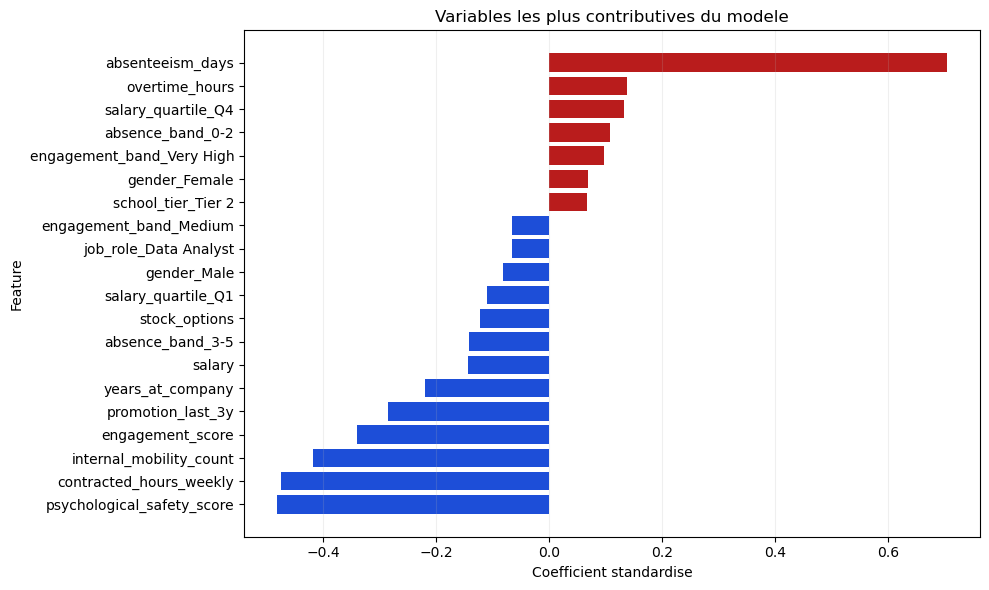

In [8]:
plot_top_coefficients(model, prepared.feature_names, top_n=20)


## 5. Experience d'oversampling

On teste ici un **random oversampling** sur le jeu d'entrainement uniquement. L'objectif n'est pas de "creer de l'information", mais de verifier si une meilleure representation de la classe minoritaire permet surtout d'ameliorer le compromis entre `recall` et `precision`.


In [9]:
oversample = random_oversample_minority(prepared.X_train, prepared.y_train, seed=42)

pd.DataFrame(
    {
        "Jeu": ["Train original", "Train oversample"],
        "Positifs": [oversample.original_positive_count, oversample.resampled_positive_count],
        "Negatifs": [oversample.original_negative_count, oversample.resampled_negative_count],
    }
)


,Jeu,Positifs,Negatifs
0,Train original,901,3898
1,Train oversample,3898,3898


In [10]:
oversampled_model = SimpleLogisticRegression(
    learning_rate=0.05,
    epochs=4000,
    reg_strength=0.02,
    class_weight=None,
)
oversampled_model.fit(oversample.X_resampled, oversample.y_resampled)

oversampled_val_scores = oversampled_model.predict_proba(prepared.X_val)
oversampled_best_threshold = find_best_threshold(prepared.y_val, oversampled_val_scores)
oversampled_test_scores = oversampled_model.predict_proba(prepared.X_test)
oversampled_metrics = classification_metrics(
    prepared.y_test,
    oversampled_test_scores,
    threshold=oversampled_best_threshold["threshold"],
)

comparison = pd.DataFrame(
    [
        (
            "Baseline ponderee",
            roc_auc_score_manual(prepared.y_test, test_scores),
            pr_auc_score_manual(prepared.y_test, test_scores),
            metrics["precision"],
            metrics["recall"],
            metrics["f1_score"],
        ),
        (
            "Random oversampling",
            roc_auc_score_manual(prepared.y_test, oversampled_test_scores),
            pr_auc_score_manual(prepared.y_test, oversampled_test_scores),
            oversampled_metrics["precision"],
            oversampled_metrics["recall"],
            oversampled_metrics["f1_score"],
        ),
    ],
    columns=["Modele", "ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-score"],
).round(4)

comparison


,Modele,ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Baseline ponderee,0.8102,0.5000,0.4000,0.6844,0.5049
1,Random oversampling,0.8082,0.4972,0.4045,0.6611,0.5019


### Interpretation attendue

- Si le `recall` augmente, l'oversampling aide le modele a rater moins de departs.
- Si la `precision` baisse fortement, cela signifie qu'il produit davantage de faux positifs.
- Si le gain reste marginal sur `PR-AUC` et `F1-score`, on peut conclure que le modele de base capte deja l'essentiel du signal utile, et que l'oversampling n'apporte qu'un ajustement secondaire.


## 6. Experience de detection d'anomalie

En complement du modele supervise, on peut aussi tester une logique semi-supervisee : apprendre le profil "normal" des collaborateurs qui restent, puis mesurer a quel point certains profils s'en ecartent.

Ici, on utilise une distance de **Mahalanobis regularisee** sur l'ensemble des variables exploitables, apres encodage des variables qualitatives et standardisation. Le profil de reference est appris uniquement sur les collaborateurs sans attrition du train.


In [11]:
numeric_data = prepare_numeric_anomaly_data(df, drop_columns=["employee_id"])

normal_train = numeric_data.X_train[numeric_data.y_train == 0]
anomaly_model = MahalanobisAnomalyDetector(regularization=0.1)
anomaly_model.fit(normal_train)

anomaly_val_scores = anomaly_model.score_samples(numeric_data.X_val)
anomaly_thresholds = np.quantile(anomaly_val_scores, np.linspace(0.70, 0.99, 60))
anomaly_best_threshold = find_best_threshold(
    numeric_data.y_val,
    anomaly_val_scores,
    thresholds=np.unique(anomaly_thresholds),
)
anomaly_test_scores = anomaly_model.score_samples(numeric_data.X_test)
anomaly_metrics = classification_metrics(
    numeric_data.y_test,
    anomaly_test_scores,
    threshold=anomaly_best_threshold["threshold"],
)

pd.DataFrame(
    [
        ("Anomaly score threshold", anomaly_best_threshold["threshold"]),
        ("ROC-AUC", roc_auc_score_manual(numeric_data.y_test, anomaly_test_scores)),
        ("PR-AUC", pr_auc_score_manual(numeric_data.y_test, anomaly_test_scores)),
        ("Precision", anomaly_metrics["precision"]),
        ("Recall", anomaly_metrics["recall"]),
        ("F1-score", anomaly_metrics["f1_score"]),
    ],
    columns=["Metrique", "Valeur"],
).round(4)


,Metrique,Valeur
0,Anomaly score threshold,8.2712
1,ROC-AUC,0.5018
2,PR-AUC,0.1939
3,Precision,0.2162
4,Recall,0.3455
5,F1-score,0.2660


In [12]:
all_comparison = pd.DataFrame(
    [
        (
            "Baseline ponderee",
            roc_auc_score_manual(prepared.y_test, test_scores),
            pr_auc_score_manual(prepared.y_test, test_scores),
            metrics["precision"],
            metrics["recall"],
            metrics["f1_score"],
        ),
        (
            "Random oversampling",
            roc_auc_score_manual(prepared.y_test, oversampled_test_scores),
            pr_auc_score_manual(prepared.y_test, oversampled_test_scores),
            oversampled_metrics["precision"],
            oversampled_metrics["recall"],
            oversampled_metrics["f1_score"],
        ),
        (
            "Detection d'anomalie",
            roc_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            pr_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            anomaly_metrics["precision"],
            anomaly_metrics["recall"],
            anomaly_metrics["f1_score"],
        ),
    ],
    columns=["Approche", "ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-score"],
).round(4)

all_comparison


,Approche,ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Baseline ponderee,0.8102,0.5000,0.4000,0.6844,0.5049
1,Random oversampling,0.8082,0.4972,0.4045,0.6611,0.5019
2,Detection d'anomalie,0.5018,0.1939,0.2162,0.3455,0.2660


### Lecture critique

- Cette approche est interessante quand la classe positive reste minoritaire, car elle ne suppose pas de modeliser finement un grand nombre de cas de depart.
- En revanche, elle repose sur une hypothese forte : les departs seraient des profils **atypiques** par rapport aux collaborateurs qui restent.
- Si les collaborateurs qui quittent l'entreprise ne sont pas des anomalies nettes mais des cas proches du reste de la population, la methode restera limitee.


## 7. Lecture business du modele

Variables associees a un **risque plus eleve** dans cette version du modele :

- absentisme plus eleve
- davantage d'heures supplementaires
- certains effets lies a des roles ou sous-populations specifiques, a interpreter avec prudence
- des situations de moindre stabilisation RH : anciennete plus faible, absence de promotion recente et mobilite interne plus faible

Variables associees a un **risque plus faible** :

- meilleure securite psychologique
- un temps contractuel plus important
- davantage de mobilite interne
- un engagement plus eleve
- la presence d'une promotion recente


## 8. Analyse critique

### Ce que le modele apporte

- un cadre robuste de priorisation des populations a surveiller
- une lecture interpretable grace aux coefficients
- une base solide pour une future industrialisation

### Limites majeures

- la cible reste **minoritaire** (18,8 % de departs), mais elle est bien plus exploitable qu'auparavant
- les performances du modele supervise sont **solides** sur ce dataset, mais elles doivent etre confirmees hors echantillon temporel
- l'oversampling n'apporte qu'un gain marginal par rapport a la regression logistique ponderee
- la detection d'anomalie reste nettement moins performante que l'approche supervisee
- plusieurs variables sont potentiellement sensibles ou discutables d'un point de vue ethique (`gender`, `accented_name_flag`)
- le resultat peut dependre de la maniere dont certaines variables ont ete construites dans le dataset, notamment l'absenteisme ou la securite psychologique

### Conclusion

Le modele devient ici un **outil d'aide a la priorisation RH credible**, utile pour cibler les actions de prevention, tout en restant insuffisant pour justifier a lui seul des decisions individuelles.
